<a href="https://colab.research.google.com/github/keertish05/big_data_project/blob/main/PS1_EarlyOutbreakDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.5 MB/s eta 0:00:00
Spark session initialized successfully!
Generating synthetic healthcare data...
Generated demographics.csv with 200 records
Generated medical_tests.json with 500 records
Generated streaming_vitals.json with 1000 records
Demographics schema:
root
 |-- patient_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- city: string (nullable = true)
 |-- zip_code: integer (nullable = true)

Test results schema:
root
 |-- test_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- test_name: string (nullable = true)
 |-- result_value: string (nullable = true)
 |-- units: string (nullable = true)
 |-- test_date: string (nullable = true)
 |-- city: string (nullable = true)

Vitals schema:
root
 |-- body_temperature: double (nullable = true)
 |-- city: string (nullable =

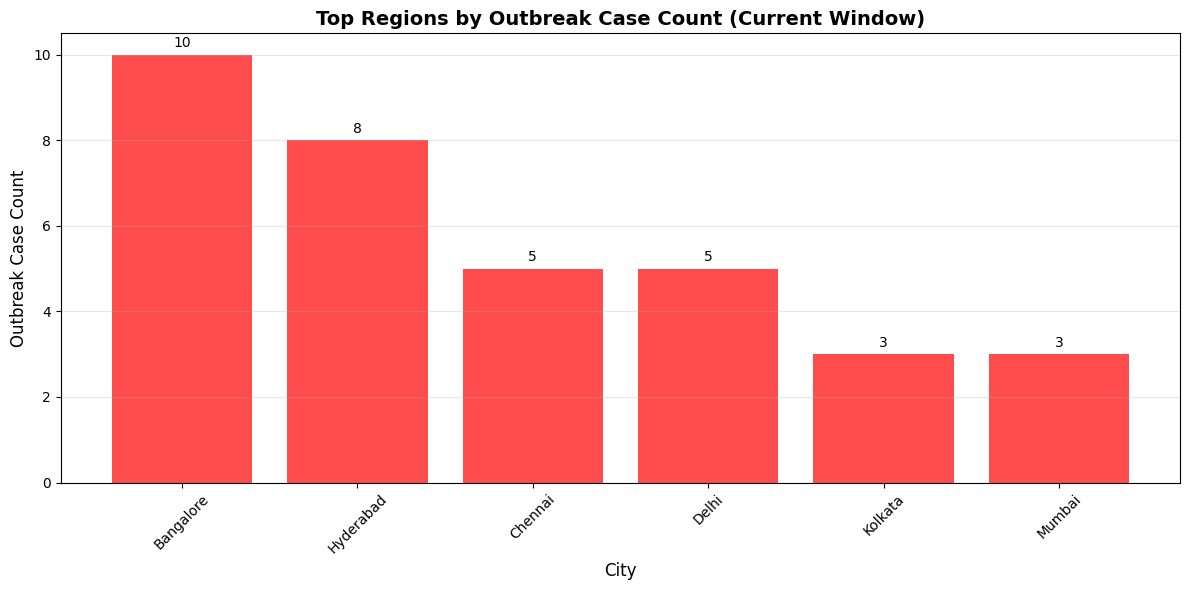

Bar chart generated successfully!


/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




Could not save map as PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

But the interactive map is displayed above!

Generating alternative map visualization...


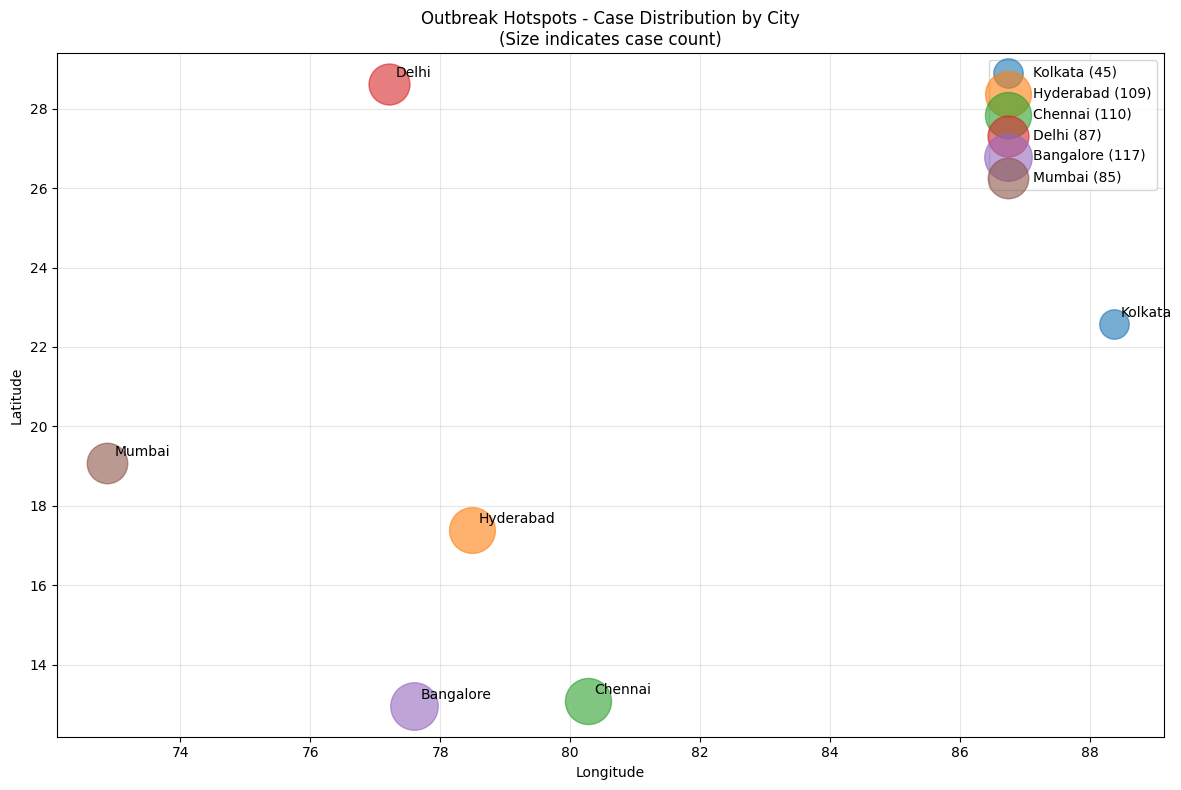

Alternative map visualization generated successfully!

SUMMARY STATISTICS
Total patients: 200
Total vitals readings: 1000
Total test results: 500
Patients with fever: 191
Patients with abnormal tests: 148
Outbreak-like cases detected: 140

Sample of outbreak cases:
+----------+----------+----------------+-------------------+
|patient_id|final_city|body_temperature|          timestamp|
+----------+----------+----------------+-------------------+
|     P1150|   Chennai|           102.9|2025-11-18 19:16:40|
|     P1074| Bangalore|           102.8|2025-11-17 23:16:40|
|     P1141|    Mumbai|           102.7|2025-11-17 06:16:40|
|     P1183| Bangalore|           101.6|2025-11-20 02:16:40|
|     P1191|   Chennai|           101.6|2025-11-15 15:16:40|
+----------+----------+----------------+-------------------+
only showing top 5 rows


Outbreak cases by city:
+----------+-----+
|final_city|count|
+----------+-----+
| Bangalore|  117|
|   Chennai|  110|
| Hyderabad|  109|
|     Delhi|   87|
| 

In [1]:
# Install required packages
!pip install pyspark plotly
!pip install -U kaleido --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime, timedelta
import random
import json
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, count, window, lit, to_timestamp
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType, TimestampType
import os

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("HealthcareOutbreakDetection") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

print("Spark session initialized successfully!")



def generate_synthetic_data():
    """Generate all required synthetic datasets"""

    # Basic pools for data
    cities = ["Delhi", "Mumbai", "Chennai", "Bangalore", "Kolkata", "Hyderabad"]
    genders = ["Male", "Female", "Other"]
    test_names = ["COVID PCR", "Blood Glucose", "Influenza Test"]

    # --- Patient Demographics ---
    demographics_data = []
    for i in range(1, 201):  # 200 patients
        age = random.randint(20, 80)
        city = random.choice(cities)
        gender = random.choice(genders)
        patient_id = f"P{1000 + i}"
        demographics_data.append({
            "patient_id": patient_id,
            "age": age,
            "gender": gender,
            "city": city,
            "zip_code": random.randint(100000, 999999)
        })

    demographics_df = pd.DataFrame(demographics_data)
    demographics_df.to_csv("demographics.csv", index=False)
    print(f"Generated demographics.csv with {len(demographics_df)} records")

    # --- Medical Test Results ---
    medical_test_results = []
    for i in range(1, 501):  # 500 tests
        test_date = (datetime.now() - timedelta(days=random.randint(0, 14))).strftime("%Y-%m-%d")
        patient_data = random.choice(demographics_data)
        patient_id = patient_data["patient_id"]
        city = patient_data["city"]
        test_name = random.choice(test_names)

        if test_name == "Blood Glucose":
            result_value = str(round(random.uniform(70, 250), 1))
            units = "mg/dl"
        else:
            result_value = random.choice(["positive", "negative"])
            units = ""

        medical_test_results.append({
            "test_id": f"T{5000 + i}",
            "patient_id": patient_id,
            "test_name": test_name,
            "result_value": result_value,
            "units": units,
            "test_date": test_date,
            "city": city
        })

    with open("medical_tests.json", "w") as f:
        json.dump(medical_test_results, f, indent=2)
    print(f"Generated medical_tests.json with {len(medical_test_results)} records")

    vitals_data = []
    for i in range(1, 1001):  # 1000 vitals records
        timestamp = (datetime.now() - timedelta(hours=random.randint(0, 168))).strftime("%Y-%m-%d %H:%M:%S")
        patient_data = random.choice(demographics_data)
        patient_id = patient_data["patient_id"]
        city = patient_data["city"]

        vitals_data.append({
            "patient_id": patient_id,
            "body_temperature": round(random.uniform(97.0, 104.0), 1),
            "heart_rate": random.randint(60, 120),
            "systolic_bp": random.randint(90, 160),
            "diastolic_bp": random.randint(60, 100),
            "timestamp": timestamp,
            "city": city
        })

    # Save as JSON lines format
    with open("streaming_vitals.json", "w") as f:
        for record in vitals_data:
            f.write(json.dumps(record) + '\n')
    print(f"Generated streaming_vitals.json with {len(vitals_data)} records")

    return demographics_df

# Generate the data
print("Generating synthetic healthcare data...")
demographics_df = generate_synthetic_data()

# Load Patient Demographics
demographics = spark.read.csv("demographics.csv", header=True, inferSchema=True)
print("Demographics schema:")
demographics.printSchema()
demographics.cache()

# Load Medical Test Results
test_results_raw = pd.read_json("medical_tests.json")
test_results = spark.createDataFrame(test_results_raw)
print("Test results schema:")
test_results.printSchema()
test_results.cache()

# Load Streaming Vitals
vitals_structured = spark.read.json("streaming_vitals.json")
print("Vitals schema:")
vitals_structured.printSchema()
vitals_structured.cache()

print(f"Demographics count: {demographics.count()}")
print(f"Test results count: {test_results.count()}")
print(f"Vitals count: {vitals_structured.count()}")

# --- Step 1: Clean and Interpolate Missing Joins ---

# Join streaming vitals to demographics - specify which city column to use
vitals_join = vitals_structured.alias("v").join(
    demographics.alias("d"),
    on='patient_id',
    how='left'
)

# Handle missing demographics in vitals - specify which city column
missing_vitals = vitals_join.filter(col("d.city").isNull())
print(f"Vitals with missing demographics: {missing_vitals.count()}")

if missing_vitals.count() > 0:
    # Calculate average age for interpolation
    avg_age = demographics.select(avg("age")).collect()[0][0]

    interpolated = missing_vitals.withColumn("final_city", lit("Unknown")) \
                                .withColumn("final_age", lit(avg_age)) \
                                .withColumn("final_gender", lit("Unknown")) \
                                .withColumn("final_zip_code", lit(0))

    # Create complete dataset with proper column names
    vitals_complete_with_data = vitals_join.filter(col("d.city").isNotNull()) \
        .withColumn("final_city", col("d.city")) \
        .withColumn("final_age", col("d.age")) \
        .withColumn("final_gender", col("d.gender")) \
        .withColumn("final_zip_code", col("d.zip_code"))

    vitals_complete = vitals_complete_with_data.union(interpolated)
else:
    vitals_complete = vitals_join.withColumn("final_city", col("d.city")) \
                                .withColumn("final_age", col("d.age")) \
                                .withColumn("final_gender", col("d.gender")) \
                                .withColumn("final_zip_code", col("d.zip_code"))

vitals_complete.cache()

# Join test results to demographics
test_results_join = test_results.alias("t").join(
    demographics.alias("d"),
    on='patient_id',
    how='left'
)

# Handle missing demographics in test results
missing_tests = test_results_join.filter(col("d.city").isNull())
print(f"Test results with missing demographics: {missing_tests.count()}")

if missing_tests.count() > 0:
    interpolated_tests = missing_tests.withColumn("final_city", lit("Unknown")) \
                                     .withColumn("final_age", lit(avg_age)) \
                                     .withColumn("final_gender", lit("Unknown")) \
                                     .withColumn("final_zip_code", lit(0))

    test_results_complete_with_data = test_results_join.filter(col("d.city").isNotNull()) \
        .withColumn("final_city", col("d.city")) \
        .withColumn("final_age", col("d.age")) \
        .withColumn("final_gender", col("d.gender")) \
        .withColumn("final_zip_code", col("d.zip_code"))

    test_results_complete = test_results_complete_with_data.union(interpolated_tests)
else:
    test_results_complete = test_results_join.withColumn("final_city", col("d.city")) \
                                            .withColumn("final_age", col("d.age")) \
                                            .withColumn("final_gender", col("d.gender")) \
                                            .withColumn("final_zip_code", col("d.zip_code"))

test_results_complete.cache()

print("Data cleaning and interpolation completed!")

# --- Step 2: Abnormality Detection (with flags) ---

# Vitals: Fever threshold detection (100.4°F = 38°C)
vitals_flagged = vitals_complete.withColumn(
    "fever_flag",
    when(col("body_temperature") > 100.4, 1).otherwise(0)
)
vitals_flagged.cache()

# Test Results: Abnormality detection
test_flagged = test_results_complete.withColumn(
    "abnormal_flag",
    when((col("test_name") == "COVID PCR") & (col("result_value") == "positive"), 1)
    .when((col("test_name") == "Influenza Test") & (col("result_value") == "positive"), 1)
    .when((col("test_name") == "Blood Glucose") & (col("result_value").cast("float") > 150), 1)
    .otherwise(0)
)
test_flagged.cache()

print("Abnormality detection completed!")
print(f"Vitals with fever: {vitals_flagged.filter(col('fever_flag') == 1).count()}")
print(f"Abnormal test results: {test_flagged.filter(col('abnormal_flag') == 1).count()}")

# --- Step 3: Merge Streaming & Batch Signals ---

# Convert timestamp for proper window operations
vitals_with_ts = vitals_flagged.withColumn("timestamp_ts", to_timestamp(col("timestamp")))

# Get recent tests (last 7 days) that are abnormal
recent_tests = test_flagged.filter(col("abnormal_flag") == 1)

# Merge based on patient_id
merged = vitals_with_ts.join(
    recent_tests.select("patient_id", "abnormal_flag"),
    on="patient_id",
    how="inner"
)

# Flag outbreak cases (fever + abnormal test)
outbreak_like = merged.filter((col("fever_flag") == 1) & (col("abnormal_flag") == 1))
outbreak_like.cache()

print(f"Outbreak-like cases detected: {outbreak_like.count()}")

# --- Step 4: Aggregate by Region and Time Window ---

# Aggregate by city and daily window
outbreak_counts = outbreak_like.groupBy(
    "final_city",
    window("timestamp_ts", "1 day")
).count().withColumnRenamed("count", "outbreak_case_count")

outbreak_counts.cache()

print("Aggregation completed!")

# =============================================================================
# 3. DASHBOARD DATA PREPARATION
# =============================================================================

# Convert to pandas for visualization
map_data_pd = outbreak_counts.select("final_city", "window", "outbreak_case_count").toPandas()

# Extract window start time for better visualization
if not map_data_pd.empty and 'window' in map_data_pd.columns:
    map_data_pd['window_start'] = map_data_pd['window'].apply(lambda x: x.start if x else None)
    map_data_pd['window_end'] = map_data_pd['window'].apply(lambda x: x.end if x else None)

    # Get latest window data for bar chart
    if not map_data_pd['window_start'].isna().all():
        latest_window = map_data_pd['window_start'].max()
        current_window_data = map_data_pd[map_data_pd['window_start'] == latest_window]

        # Sort by case count for bar chart
        bar_chart_data = current_window_data.sort_values('outbreak_case_count', ascending=False).head(10)
    else:
        bar_chart_data = pd.DataFrame(columns=['final_city', 'outbreak_case_count'])
else:
    # Create empty DataFrames if no outbreak cases
    map_data_pd = pd.DataFrame(columns=['final_city', 'outbreak_case_count', 'window_start', 'window_end'])
    bar_chart_data = pd.DataFrame(columns=['final_city', 'outbreak_case_count'])

print("Dashboard data prepared!")

# Save outputs
if not map_data_pd.empty:
    map_data_pd.to_csv("outbreak_map_data.csv", index=False)
    print("Saved outbreak_map_data.csv")

if not bar_chart_data.empty:
    bar_chart_data.to_csv("outbreak_barchart.csv", index=False)
    print("Saved outbreak_barchart.csv")

print("Output files saved!")


print("\n" + "="*50)
print("OUTBREAK DETECTION DASHBOARD")
print("="*50)

# --- Bar Chart Visualization ---
plt.figure(figsize=(12, 6))

if not bar_chart_data.empty and 'final_city' in bar_chart_data.columns and 'outbreak_case_count' in bar_chart_data.columns:
    plt.bar(bar_chart_data['final_city'], bar_chart_data['outbreak_case_count'], color='red', alpha=0.7)
    plt.xlabel('City', fontsize=12)
    plt.ylabel('Outbreak Case Count', fontsize=12)
    plt.title('Top Regions by Outbreak Case Count (Current Window)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, v in enumerate(bar_chart_data['outbreak_case_count']):
        plt.text(i, v + 0.1, str(v), ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('outbreak_bar_chart.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Bar chart generated successfully!")
else:
    print("No outbreak cases detected in current window for bar chart.")

# --- Map Visualization ---
# Create synthetic coordinates for cities (for demo purposes)
city_coordinates = {
    "Delhi": {"lat": 28.6139, "lon": 77.2090},
    "Mumbai": {"lat": 19.0760, "lon": 72.8777},
    "Chennai": {"lat": 13.0827, "lon": 80.2707},
    "Bangalore": {"lat": 12.9716, "lon": 77.5946},
    "Kolkata": {"lat": 22.5726, "lon": 88.3639},
    "Hyderabad": {"lat": 17.3850, "lon": 78.4867},
    "Unknown": {"lat": 20.5937, "lon": 78.9629}  # Center of India
}

# Prepare map data
if not map_data_pd.empty and 'final_city' in map_data_pd.columns:
    # Use the latest data for map
    if 'window_start' in map_data_pd.columns and not map_data_pd['window_start'].isna().all():
        latest_window_map = map_data_pd['window_start'].max()
        map_display_data = map_data_pd[map_data_pd['window_start'] == latest_window_map]
    else:
        map_display_data = map_data_pd

    map_display_data = map_display_data.copy()
    map_display_data['latitude'] = map_display_data['final_city'].map(
        lambda x: city_coordinates.get(x, {"lat": 20.5937, "lon": 78.9629})["lat"]
    )
    map_display_data['longitude'] = map_display_data['final_city'].map(
        lambda x: city_coordinates.get(x, {"lat": 20.5937, "lon": 78.9629})["lon"]
    )

    # Use Plotly for interactive map
    fig = px.scatter_mapbox(
        map_display_data,
        lat="latitude",
        lon="longitude",
        color="outbreak_case_count",
        size="outbreak_case_count",
        hover_name="final_city",
        hover_data={"outbreak_case_count": True, "final_city": False},
        color_continuous_scale="reds",
        size_max=30,
        zoom=4,
        title="Outbreak Hotspots - Case Distribution by City"
    )

    fig.update_layout(
        mapbox_style="carto-positron",
        margin={"r": 0, "t": 30, "l": 0, "b": 0},
        height=500
    )

    fig.show()

    # Save as static image with error handling
    try:
        fig.write_image("outbreak_map.png")
        print("Map visualization generated and saved successfully!")
    except Exception as e:
        print(f"Could not save map as PNG: {e}")
        print("But the interactive map is displayed above!")
else:
    print("No outbreak cases detected for map visualization.")

# --- Alternative: Simple Matplotlib Map ---
print("\nGenerating alternative map visualization...")
if not map_data_pd.empty and 'final_city' in map_data_pd.columns:
    plt.figure(figsize=(12, 8))

    # Create a simple geographical plot
    cities_present = map_data_pd['final_city'].unique()

    # Plot each city with size based on outbreak count
    for city in cities_present:
        city_data = map_data_pd[map_data_pd['final_city'] == city]
        total_cases = city_data['outbreak_case_count'].sum()

        if city in city_coordinates:
            lat = city_coordinates[city]["lat"]
            lon = city_coordinates[city]["lon"]

            plt.scatter(lon, lat, s=total_cases*10, alpha=0.6, label=f"{city} ({total_cases})")
            plt.annotate(city, (lon, lat), xytext=(5, 5), textcoords='offset points')

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Outbreak Hotspots - Case Distribution by City\n(Size indicates case count)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('outbreak_map_simple.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Alternative map visualization generated successfully!")

# --- Summary Statistics ---
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Total patients: {demographics.count()}")
print(f"Total vitals readings: {vitals_structured.count()}")
print(f"Total test results: {test_results.count()}")
print(f"Patients with fever: {vitals_flagged.filter(col('fever_flag') == 1).select('patient_id').distinct().count()}")
print(f"Patients with abnormal tests: {test_flagged.filter(col('abnormal_flag') == 1).select('patient_id').distinct().count()}")
print(f"Outbreak-like cases detected: {outbreak_like.select('patient_id').distinct().count()}")

# Show sample of outbreak cases
if outbreak_like.count() > 0:
    print("\nSample of outbreak cases:")
    outbreak_like.select("patient_id", "final_city", "body_temperature", "timestamp").show(5)

# Show outbreak counts by city
print("\nOutbreak cases by city:")
outbreak_by_city = outbreak_like.groupBy("final_city").count().orderBy("count", ascending=False)
outbreak_by_city.show()

# =============================================================================
# 5. CLEANUP AND SPARK SESSION STOP
# =============================================================================

# Unpersist cached DataFrames
try:
    demographics.unpersist()
    test_results.unpersist()
    vitals_structured.unpersist()
    vitals_complete.unpersist()
    test_results_complete.unpersist()
    vitals_flagged.unpersist()
    test_flagged.unpersist()
    outbreak_like.unpersist()
    outbreak_counts.unpersist()
    print("All DataFrames unpersisted successfully!")
except:
    print("Some DataFrames may have already been unpersisted")

# Stop Spark session
spark.stop()
print("\nSpark session stopped successfully!")

print("\n" + "="*50)
print("PIPELINE EXECUTION COMPLETED SUCCESSFULLY!")
print("="*50)
print("Generated files:")
print("- outbreak_map_data.csv")
print("- outbreak_barchart.csv")
print("- outbreak_bar_chart.png")
print("- outbreak_map.png (if Kaleido worked)")
print("- outbreak_map_simple.png (alternative)")
print("="*50)

# List generated files
print("\nGenerated files list:")
!ls -la *.csv *.json *.png 2>/dev/null || echo "No files found"'